In [39]:
pip install openneuro-py

Note: you may need to restart the kernel to use updated packages.


In [1]:
!dir "C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/data"

 Volume in drive C is OS
 Volume Serial Number is 125E-D761

 Directory of C:\Users\ssrko\OneDrive\Documents\EEG-Pain-Analysis\EEG-Pain-Project\data

23-05-2026  17:26    <DIR>          .
23-05-2026  17:26    <DIR>          ..
23-05-2026  15:04                42 CHANGES
23-05-2026  15:04               559 dataset_description.json
23-05-2026  15:04               671 participants.json
23-05-2026  15:04               948 participants.tsv
23-05-2026  15:04             1,531 README
30-07-2026  23:49    <DIR>          sub-001
23-05-2026  17:26    <DIR>          sub-002
23-05-2026  17:26    <DIR>          sub-003
23-05-2026  17:26    <DIR>          sub-004
23-05-2026  17:26    <DIR>          sub-005
23-05-2026  17:26    <DIR>          sub-006
23-05-2026  17:26    <DIR>          sub-007
23-05-2026  17:26    <DIR>          sub-008
23-05-2026  17:26    <DIR>          sub-009
23-05-2026  17:26    <DIR>          sub-010
23-05-2026  17:26    <DIR>          sub-011
23-05-2026  17:26    <DIR>        

In [2]:
with open ("C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/data/README", "r") as f:
    print(f.read())

1.Study introduction:
First, participants underwent a series of laser stimulations of varying intensities. The experimenter determined the energy intensity corresponding to an average score of 7 points among the participants. Subsequently, each participant received a fixed-intensity laser stimulation approximately every 20 seconds, for a total of 16 trials, during which they provided pain ratings ranging from 0 to 10. A rating of 0 indicated no sensation, 4 denoted the onset of pain perception, 6 represented moderate pain, 8 indicated severe pain, and 10 signified intolerable pain.
2.Participant task information(description of the experiment): 
Participants received laser stimulation and used a computer mouse to click on the appropriate position on the screen, corresponding to a scale of 0 to 10.
3.Participant instructions(as exact as possible):
Participants were instructed to concentrate on the laser stimuli, maintain open eyes, and fixate their gaze on a cross displayed on the screen

In [3]:
!dir "C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/data/sub-001"

 Volume in drive C is OS
 Volume Serial Number is 125E-D761

 Directory of C:\Users\ssrko\OneDrive\Documents\EEG-Pain-Analysis\EEG-Pain-Project\data\sub-001

30-07-2026  23:49    <DIR>          .
23-05-2026  17:26    <DIR>          ..
30-07-2026  23:06               944 sub-001_task-26ByBiosemi_channels.txt
30-07-2026  23:05        65,511,936 sub-001_task-26ByBiosemi_eeg.bdf
30-07-2026  23:06               613 sub-001_task-26ByBiosemi_eeg.json
30-07-2026  23:07             1,963 sub-001_task-26ByBiosemi_electrodes.txt
30-07-2026  23:07             1,142 sub-001_task-26ByBiosemi_events.txt
               5 File(s)     65,516,598 bytes
               2 Dir(s)  325,611,687,936 bytes free


In [20]:
#step 1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
loo = LeaveOneOut()
from scipy import stats

In [19]:
#Step 2: Data Paths & Inspecting the data
participants = pd.read_csv ("C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/data/participants.tsv", sep="\t")
print(participants.columns.tolist())
participants.head(10)

['participant_id', 'ID', 'Pre_ID', 'Gender', 'Age', 'Education', 'Pain_Threshold_7']


,participant_id,ID,Pre_ID,Gender,Age,Education,Pain_Threshold_7
0,sub-001,1,1,M,25,19,3.50
1,sub-002,2,2,F,22,14,3.50
2,sub-003,3,3,F,21,15,3.75
3,sub-004,4,4,M,22,16,3.25
4,sub-005,5,6,F,23,16,3.00
5,sub-006,6,7,F,19,13,4.25
6,sub-007,7,8,M,23,17,3.75
7,sub-008,8,9,M,19,13,4.25
8,sub-009,9,13,F,20,16,3.50
9,sub-010,10,14,F,23,16,2.75


In [21]:

# step 3: Load & Merging 
group_results = pd.read_csv("C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/group_results.csv")
participants = pd.read_csv("C:/Users/ssrko/OneDrive/Documents/EEG-Pain-Analysis/EEG-Pain-Project/data/participants.tsv", sep="\t")

merged = group_results.merge(participants, left_on="subject", right_on = "participant_id")
print (merged.shape)
merged.head(27)

(26, 17)


,subject,event_id,n_epochs,n2_latency_ms,n2_amplitude_uv,p2_latency_ms,p2_amplitude_uv,np_amplitude_uv,peak_alpha_hz,alpha_power_uv2,participant_id,ID,Pre_ID,Gender,Age,Education,Pain_Threshold_7
0,sub-001,54,16,299.8,4.67,252.9,21.12,16.46,8.0,1.4448,sub-001,1,1,M,25,19,3.50
1,sub-002,54,16,150.4,-2.06,250.0,15.69,17.75,8.0,17.1038,sub-002,2,2,F,22,14,3.50
2,sub-003,54,16,299.8,-16.34,257.8,-3.37,12.97,12.0,2.6335,sub-003,3,3,F,21,15,3.75
3,sub-004,54,16,286.1,-23.72,374.0,-3.10,20.62,8.0,2.0525,sub-004,4,4,M,22,16,3.25
4,sub-005,54,16,150.4,-14.13,264.6,-0.45,13.69,8.0,1.1268,sub-005,5,6,F,23,16,3.00
5,sub-006,54,16,299.8,-26.20,486.3,-2.04,24.15,8.0,2.5228,sub-006,6,7,F,19,13,4.25
6,sub-007,54,16,290.0,-13.43,500.0,24.53,37.96,8.0,1.1378,sub-007,7,8,M,23,17,3.75
7,sub-008,54,16,299.8,-6.93,250.0,11.01,17.93,12.0,1.4026,sub-008,8,9,M,19,13,4.25
8,sub-009,54,16,250.0,-20.56,420.9,13.57,34.13,8.0,2.2827,sub-009,9,13,F,20,16,3.50
9,sub-010,54,16,275.4,-8.93,500.0,31.84,40.77,8.0,446.0963,sub-010,10,14,F,23,16,2.75


In [23]:
# step 4: Classfication Label

threshold_median = merged ["Pain_Threshold_7"].median ()
print (f"Median threshold: {threshold_median}")

#1 =high sensitivity (low threhsold), 0=low sensitivity (high threshold)
merged['pain_sensitivity']=(merged['Pain_Threshold_7'] <= threshold_median).astype(int)
print(merged['pain_sensitivity'].value_counts())

Median threshold: 3.75
pain_sensitivity
1    16
0    10
Name: count, dtype: int64


In [24]:
#step 5: scaling features

feature_cols = ['n2_latency_ms','n2_amplitude_uv', 'p2_latency_ms', 
                'p2_amplitude_uv', 'np_amplitude_uv', 'peak_alpha_hz', 'alpha_power_uv2' ]

X = merged[feature_cols].values
Y= merged['pain_sensitivity'].values

print (X.shape, Y.shape)

(26, 7) (26,)


In [25]:
# step 6: Baseline model- all 7 features, building the LOOCV loop

#LDA pipeline
lda_pipeline = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda_preds = cross_val_predict(lda_pipeline, X,Y, cv=loo)

#SVM Pipeline( Linear kernel frist -simplest, most interpretable)

svm_pipeline = make_pipeline(StandardScaler(), SVC (kernel ='linear'))
svm_preds = cross_val_predict (svm_pipeline, X,Y, cv=loo)

print ("LDA Results")
print (f"Balanced Accuracy:{balanced_accuracy_score (Y,lda_preds):.3f}")
print(confusion_matrix(Y, lda_preds))
print(classification_report(Y, lda_preds))

print ("n===SVM (linear) Results===")
print(f"Balanced Accuracy: {balanced_accuracy_score(Y, svm_preds):.3f}")
print (confusion_matrix(Y, svm_preds))
print(classification_report(Y, svm_preds))

LDA Results
Balanced Accuracy:0.494
[[ 3  7]
 [ 5 11]]
              precision    recall  f1-score   support

           0       0.38      0.30      0.33        10
           1       0.61      0.69      0.65        16

    accuracy                           0.54        26
   macro avg       0.49      0.49      0.49        26
weighted avg       0.52      0.54      0.53        26

n===SVM (linear) Results===
Balanced Accuracy: 0.450
[[4 6]
 [8 8]]
              precision    recall  f1-score   support

           0       0.33      0.40      0.36        10
           1       0.57      0.50      0.53        16

    accuracy                           0.46        26
   macro avg       0.45      0.45      0.45        26
weighted avg       0.48      0.46      0.47        26



In [26]:
# step 7: Quantify how exteme these outliners really
alpha_mean = merged['alpha_power_uv2'].mean()
alpha_std = merged ['alpha_power_uv2'].std()

merged['alpha_zscore']= (merged['alpha_power_uv2']-alpha_mean)/alpha_std

print(merged[['subject', 'alpha_power_uv2', 'alpha_zscore']].sort_values('alpha_zscore', ascending =False))

    subject  alpha_power_uv2  alpha_zscore
13  sub-014         494.5245      3.578008
9   sub-010         446.0963      3.196799
12  sub-013          32.0129     -0.062707
1   sub-002          17.1038     -0.180066
16  sub-017           6.5195     -0.263381
11  sub-012           5.8257     -0.268842
21  sub-022           3.3771     -0.288117
2   sub-003           2.6335     -0.293970
19  sub-020           2.5241     -0.294831
5   sub-006           2.5228     -0.294842
8   sub-009           2.2827     -0.296732
15  sub-016           2.1677     -0.297637
3   sub-004           2.0525     -0.298544
20  sub-021           2.0425     -0.298622
25  sub-026           2.0079     -0.298895
10  sub-011           1.9748     -0.299155
18  sub-019           1.8830     -0.299878
14  sub-015           1.6900     -0.301397
17  sub-018           1.6614     -0.301622
0   sub-001           1.4448     -0.303327
7   sub-008           1.4026     -0.303659
24  sub-025           1.1803     -0.305409
22  sub-023

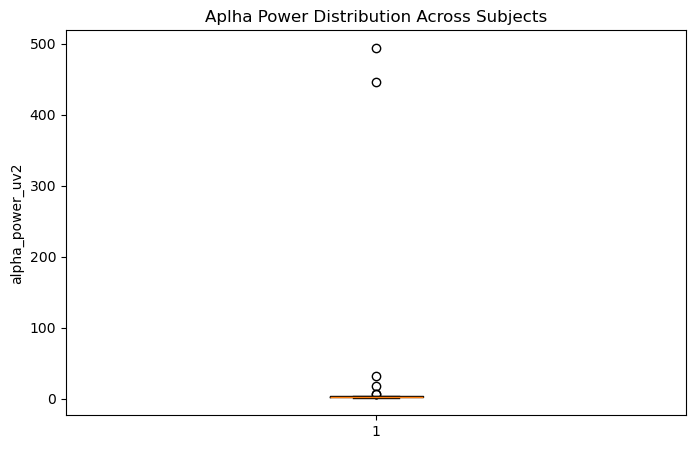

In [8]:
#step 7(a): Visualize

plt.figure(figsize=(8,5))
plt.boxplot(merged['alpha_power_uv2'])
plt.title('Aplha Power Distribution Across Subjects')
plt.ylabel('alpha_power_uv2')
plt.show()

In [9]:
clean_merged = merged[~merged['subject'].isin(['sub-010', 'sub-014'])].copy()
print(clean_merged.shape)  # should print (24, ...)

X_clean = clean_merged[feature_cols].values
y_clean = clean_merged['pain_sensitivity'].values

loo = LeaveOneOut()
lda_preds_clean = cross_val_predict(lda_pipeline, X_clean, y_clean, cv=loo)
svm_preds_clean = cross_val_predict(svm_pipeline, X_clean, y_clean, cv=loo)

print("=== LDA (outliers removed) ===")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_clean, lda_preds_clean):.3f}")
print(confusion_matrix(y_clean, lda_preds_clean))

print("\n=== SVM (outliers removed) ===")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_clean, svm_preds_clean):.3f}")
print(confusion_matrix(y_clean, svm_preds_clean))

(24, 19)
=== LDA (outliers removed) ===
Balanced Accuracy: 0.571
[[5 5]
 [5 9]]

=== SVM (outliers removed) ===
Balanced Accuracy: 0.486
[[4 6]
 [6 8]]


In [27]:
#step 8 : Individual feature correlations

print(f"{'Feature':<20} {'Correlation':>12} {'p-value':>10}")
print("-" * 44)

correlations = []
for col in feature_cols:
    corr, pval = stats.pointbiserialr(y_clean, clean_merged[col])
    correlations.append((col, corr, pval))
    print(f"{col:<20} {corr:>12.3f} {pval:>10.3f}")

# Sort by absolute strength of correlation, strongest first
correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)
print("\nRanked by strength:")
for col, corr, pval in correlations_sorted:
    print(f"  {col}: {corr:.3f} (p={pval:.3f})")

Feature               Correlation    p-value
--------------------------------------------
n2_latency_ms              -0.026      0.906
n2_amplitude_uv            -0.085      0.693
p2_latency_ms              -0.445      0.030
p2_amplitude_uv            -0.240      0.258
np_amplitude_uv            -0.257      0.225
peak_alpha_hz              -0.192      0.370
alpha_power_uv2            -0.095      0.658

Ranked by strength:
  p2_latency_ms: -0.445 (p=0.030)
  np_amplitude_uv: -0.257 (p=0.225)
  p2_amplitude_uv: -0.240 (p=0.258)
  peak_alpha_hz: -0.192 (p=0.370)
  alpha_power_uv2: -0.095 (p=0.658)
  n2_amplitude_uv: -0.085 (p=0.693)
  n2_latency_ms: -0.026 (p=0.906)


In [28]:
#step 9: Feature-selected models

selected_features = ['p2_latency_ms', 'np_amplitude_uv', 'p2_amplitude_uv']

X_selected = clean_merged[selected_features].values
y_selected = clean_merged['pain_sensitivity'].values

lda_preds_sel = cross_val_predict(lda_pipeline, X_selected, y_selected, cv=loo)
svm_preds_sel = cross_val_predict(svm_pipeline, X_selected, y_selected, cv=loo)

print("=== LDA (3 selected features) ===")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_selected, lda_preds_sel):.3f}")
print(confusion_matrix(y_selected, lda_preds_sel))

print("\n=== SVM (3 selected features) ===")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_selected, svm_preds_sel):.3f}")
print(confusion_matrix(y_selected, svm_preds_sel))

=== LDA (3 selected features) ===
Balanced Accuracy: 0.521
[[4 6]
 [5 9]]

=== SVM (3 selected features) ===
Balanced Accuracy: 0.586
[[6 4]
 [6 8]]


In [29]:
X_single = clean_merged[['p2_latency_ms']].values

lda_preds_single = cross_val_predict(lda_pipeline, X_single, y_selected, cv=loo)

print("=== LDA (p2_latency_ms only) ===")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_selected, lda_preds_single):.3f}")
print(confusion_matrix(y_selected, lda_preds_single))

=== LDA (p2_latency_ms only) ===
Balanced Accuracy: 0.671
[[7 3]
 [5 9]]


In [30]:
#Step 10: Permutation test

n_permutations = 1000
permuted_accuracies = []

np.random.seed(42)  # reproducibility

for i in range(n_permutations):
    y_shuffled = np.random.permutation(y_selected)
    preds_shuffled = cross_val_predict(lda_pipeline, X_single, y_shuffled, cv=loo)
    acc_shuffled = balanced_accuracy_score(y_shuffled, preds_shuffled)
    permuted_accuracies.append(acc_shuffled)

permuted_accuracies = np.array(permuted_accuracies)
real_accuracy = 0.671

p_value = (permuted_accuracies >= real_accuracy).mean()

print(f"Real accuracy: {real_accuracy}")
print(f"Mean chance accuracy: {permuted_accuracies.mean():.3f}")
print(f"P-value (probability of seeing this by chance): {p_value:.3f}")

Real accuracy: 0.671
Mean chance accuracy: 0.455
P-value (probability of seeing this by chance): 0.032


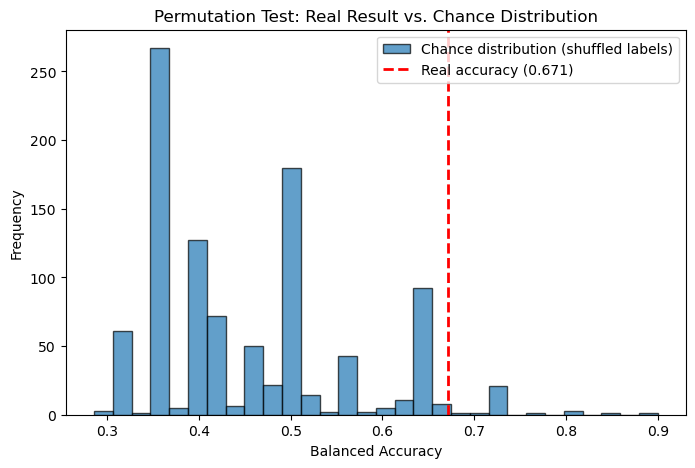

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(permuted_accuracies, bins=30, edgecolor="black", alpha=0.7, label="Chance distribution (shuffled labels)")
plt.axvline(real_accuracy, color="red", linestyle="--", linewidth=2, label=f"Real accuracy ({real_accuracy:.3f})")
plt.xlabel("Balanced Accuracy")
plt.ylabel("Frequency")
plt.title("Permutation Test: Real Result vs. Chance Distribution")
plt.legend()
plt.show()